## Anomaly Detection Model Selection via Statistical Diagnostics

We've trained several anomaly detection models to identify sales drops in hourly retail data. The next step is critical: determining which configuration delivers the most reliable and actionable results.

Generating a large volume of anomaly alerts is trivial. Ensuring those alerts represent genuine, operationally meaningful deviations is the actual challenge. A model that triggers on every zero-sale interval provides no value. Similarly, a model that overwhelms analysts with excessive daily alerts undermines its own utility. The goal is to isolate configurations that detect *real* sales deterioration with both statistical rigor and practical restraint.

This notebook implements a structured evaluation framework to achieve that.

### Approach: Statistical Diagnostics Over Subjective Judgment

In the absence of large-scale ground-truth labels, we apply a statistics-driven methodology. Each detected anomaly is enriched with historical context from the pre-test period and evaluated across three dimensions:

**Signal strength.**  
An anomaly that deviates marginally from expected behavior is not actionable. We compute z-scores against two reference baselines for every flagged event: the product's entire pre-test history and its performance during July alone — the last complete month of normal operations before the test window. Higher absolute z-score values indicate stronger, non-random deviations. We specifically measure the proportion of anomalies exceeding |z| > 2 and |z| > 3, widely accepted thresholds for statistically noteworthy and extreme outliers, respectively.

**Anomaly composition.**  
The nature of flagged events matters as much as their magnitude. We track the percentage of anomalies where sales are zero — a high share suggests the model is capturing routine non-trading patterns rather than genuine drops. We also measure the proportion of severe declines, defined as deviations greater than 50% below historical norms. Critically, we verify that stock was available at the time of each anomaly; a properly functioning detection system should only flag events where product was present to sell.

**Operational viability.**  
Even a statistically perfect model fails in practice if its output is unmanageable. We assess total alert volume, breadth of product coverage, and average daily alert frequency. Beyond sheer numbers, we validate the temporal profile of detected anomalies — all events should concentrate within working hours and skew toward weekdays, confirming that the mandatory preprocessing filters function correctly across all model configurations.

### Models Under Evaluation

Seven configurations spanning three architectures — LightGBM, Temporal Convolutional Network (TCN), and Isolation Forest — are subjected to this framework. Configurations differ in their threshold mechanisms: some rely on standard deviation-based cutoffs, others on z-score-based thresholds.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = r'C:\Users\User\Desktop\диплом\data_v1.csv'

MODELS = {
    'LightGBM_sigma5':   r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_5.csv',
    'LightGBM_sigma3_5': r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_3_5.csv',
    'LightGBM_zscore_4_5': r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_z_4_5.csv',
    'TCN_sigma_5':        r'C:\Users\User\Desktop\диплом\tcn_anomalies_5.csv',
    'TCN_sigma_3_5':      r'C:\Users\User\Desktop\диплом\tcn_anomalies_3_5.csv',
    'TCN_zscore_4_5':      r'C:\Users\User\Desktop\диплом\TCN_zscore_4_5.csv',
    'Isolation_forest': r'C:\Users\User\Desktop\диплом\isolation_forest_final_an.csv'
}

In [2]:
for model_name, path in MODELS.items():
    df = pd.read_csv(path)
    print(f"\n{model_name}")
    display(df.head(1))


LightGBM_sigma5


,date,product,category,stocks,sales,price,predicted_sales,residual,residual_zscore
0,2025-08-01 08:00:00,178462000325840,163050201,144.0,0.0,83.767,4.851005,4.851005,5.345771



LightGBM_sigma3_5


,date,product,category,stocks,sales,price,predicted_sales,residual,residual_zscore
0,2025-08-01 08:00:00,178462000325840,163050201,144.0,0.0,83.767,4.851005,4.851005,5.345771



LightGBM_zscore_4_5


...

,date,product,category,stocks,sales,price,hour,dayofweek,is_weekend,sales_log,stocks_lag_1h,product_id,category_id,predicted_sales,real_sales,drop_amount,mandatory_filter
0,2025-08-06 10:00:00,1784610E0073977,165150104,23.463999,2.147,993.9191,10,2,0,1.14645,25.610998,2,114,5.226223,2.147,3.079223,True



TCN_zscore_4_5


,date,product,category,stocks,sales,price,hour,dayofweek,is_weekend,sales_log,stocks_lag_1h,product_id,category_id,predicted_sales,real_sales,drop_amount,residual_zscore,mandatory_filter
0,2025-08-06 08:00:00,1784610E0073977,165150104,31.555998,17.459,993.9191,8,2,0,2.915552,49.015,2,114,1.18228,17.459002,-16.276722,-6.96529,True



Isolation_forest


,date,product,category,stocks,sales,price
0,2025-08-01 21:00:00,178462000403225,161010701,1.0,0.0,2749.5


# Load full original dataset for statistical baseline computation

In [3]:
df_full = pd.read_csv(DATA_PATH)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['product'] = df_full['product'].astype(str)
print(f"Dataset shape: {df_full.shape}, period: {df_full['date'].min()} — {df_full['date'].max()}")

Dataset shape: (64081080, 6), period: 2025-01-15 00:00:00 — 2025-12-27 23:00:00


# Evaluation function — enriches anomalies with statistical context and computes quality metrics

In [4]:
def evaluate_anomaly_set(anomaly_df, full_df, model_name="Model", test_start="2025-08-01"):

    # Historical statistics per product (pre-test period, starting from first positive sale)
    pre_test = full_df[full_df['date'] < test_start].copy()

    first_pos = (pre_test[pre_test['sales'] > 0]
                 .groupby('product')['date'].min()
                 .reset_index(name='first_positive_date'))

    pre_test = pre_test.merge(first_pos, on='product', how='left')
    pre_test = pre_test[pre_test['date'] >= pre_test['first_positive_date']].copy()

    stats_full = pre_test.groupby('product').agg(
        mean_sales_hist   = ('sales', 'mean'),
        std_sales_hist    = ('sales', 'std'),
        median_sales_hist = ('sales', 'median'),
        pos_rate_hist     = ('sales', lambda x: (x > 0).mean()),
    ).reset_index()

    stats_july = (pre_test[pre_test['date'].dt.month == 7]
                  .groupby('product').agg(
                      mean_sales_july = ('sales', 'mean'),
                      std_sales_july  = ('sales', 'std'),
                  ).reset_index())

    # Enrich anomalies with historical context
    anom = anomaly_df.copy()
    anom['date']    = pd.to_datetime(anom['date'])
    anom['product'] = anom['product'].astype(str)
    anom['hour']    = anom['date'].dt.hour
    anom['weekday'] = anom['date'].dt.dayofweek

    anom = anom.merge(stats_full, on='product', how='left')
    anom = anom.merge(stats_july, on='product', how='left')

    # Avoid division by zero
    for col in ['std_sales_hist', 'std_sales_july', 'mean_sales_hist', 'mean_sales_july']:
        anom[col] = anom[col].replace(0, np.nan).fillna(1)

    # Z-scores
    anom['z_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['std_sales_hist']
    anom['z_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['std_sales_july']

    # Percentage deviation from baselines
    anom['dev_pct_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['mean_sales_hist'] * 100
    anom['dev_pct_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['mean_sales_july'] * 100

    # Previous-hour stock
    stock_prev = (full_df[['date', 'product', 'stocks']]
                  .rename(columns={'stocks': 'stocks_prev', 'date': 'prev_date'}))
    anom['prev_date'] = anom['date'] - pd.Timedelta(hours=1)
    anom = anom.merge(stock_prev, on=['prev_date', 'product'], how='left')

    # Masks
    drop_mask      = anom['sales'] < anom['mean_sales_hist']
    zero_mask      = anom['sales'] == 0
    deep_drop_mask = anom['dev_pct_hist'] < -50
    stock_ok_mask  = (anom['stocks_prev'] > 0) & (anom['stocks'] > 0)

    n = len(anom)

    # Quality metrics
    metrics = {
        'Model': model_name,

        'Anomalies found': n,
        'Unique products': anom['product'].nunique(),
        'Unique days': anom['date'].dt.date.nunique(),
        'Anomalies/day (avg)': round(n / max(anom['date'].dt.date.nunique(), 1), 1),

        'Mean deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].mean(), 1),
        'Median deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].median(), 1),
        'Mean deviation from July (%)': round(anom.loc[drop_mask, 'dev_pct_july'].mean(), 1),

        'Mean |z_hist|': round(anom['z_hist'].abs().mean(), 3),
        'Mean |z_july|': round(anom['z_july'].abs().mean(), 3),
        '% |z_hist| > 2': round((anom['z_hist'].abs() > 2).mean() * 100, 1),
        '% |z_hist| > 3': round((anom['z_hist'].abs() > 3).mean() * 100, 1),
        '% |z_july| > 2': round((anom['z_july'].abs() > 2).mean() * 100, 1),
        '% |z_july| > 3': round((anom['z_july'].abs() > 3).mean() * 100, 1),

        '% zero sales': round(zero_mask.mean() * 100, 1),
        '% drops > 50% below norm': round(deep_drop_mask.mean() * 100, 1),
        '% anomalies with stock': round(stock_ok_mask.mean() * 100, 1),

        'Peak hour (mode)': int(anom['hour'].mode().iloc[0]),
        '% working hours (7–22)': round(((anom['hour'] >= 7) & (anom['hour'] <= 22)).mean() * 100, 1),
        '% weekdays': round((anom['weekday'] < 5).mean() * 100, 1),
    }

    return metrics, anom

# Run evaluation across all models

In [5]:
all_metrics = []
all_anom    = {}

for model_name, model_path in MODELS.items():
    anom_df = pd.read_csv(model_path)
    anom_df['date'] = pd.to_datetime(anom_df['date'])

    metrics, anom_enriched = evaluate_anomaly_set(
        anomaly_df  = anom_df,
        full_df     = df_full,
        model_name  = model_name,
        test_start  = "2025-08-01"
    )
    all_metrics.append(metrics)
    all_anom[model_name] = anom_enriched
    print(f"{model_name}: {metrics['Anomalies found']} anomalies, "
          f"{metrics['Unique products']} products, "
          f"mean |z_hist| = {metrics['Mean |z_hist|']}")

LightGBM_sigma5: 926 anomalies, 142 products, mean |z_hist| = 0.667
LightGBM_sigma3_5: 1869 anomalies, 221 products, mean |z_hist| = 0.603
LightGBM_zscore_4_5: 948 anomalies, 138 products, mean |z_hist| = 8.191
TCN_sigma_5: 996 anomalies, 43 products, mean |z_hist| = 0.471
TCN_sigma_3_5: 1658 anomalies, 81 products, mean |z_hist| = 0.461
TCN_zscore_4_5: 1128 anomalies, 179 products, mean |z_hist| = 8.82
Isolation_forest: 1942 anomalies, 106 products, mean |z_hist| = 1.01


Model,LightGBM_sigma5,LightGBM_sigma3_5,LightGBM_zscore_4_5,TCN_sigma_5,TCN_sigma_3_5,TCN_zscore_4_5,Isolation_forest
Anomalies found,926.000000,1869.000000,948.000000,996.000000,1658.000000,1128.000000,1942.000000
Unique products,142.000000,221.000000,138.000000,43.000000,81.000000,179.000000,106.000000
Unique days,30.000000,30.000000,30.000000,25.000000,25.000000,25.000000,31.000000
Anomalies/day (avg),30.900000,62.300000,31.600000,39.800000,66.300000,45.100000,62.600000
Mean deviation from norm (%),-86.500000,-90.300000,nan,-69.500000,-75.500000,nan,-98.000000
Median deviation from norm (%),-100.000000,-100.000000,nan,-93.700000,-100.000000,nan,-100.000000
Mean deviation from July (%),-90.800000,-93.100000,nan,-77.200000,-81.200000,nan,-98.700000
Mean |z_hist|,0.667000,0.603000,8.191000,0.471000,0.461000,8.820000,1.010000
Mean |z_july|,0.612000,0.561000,6.413000,0.489000,0.484000,7.161000,0.766000
% |z_hist| > 2,5.200000,4.400000,96.600000,1.400000,1.000000,96.600000,11.100000


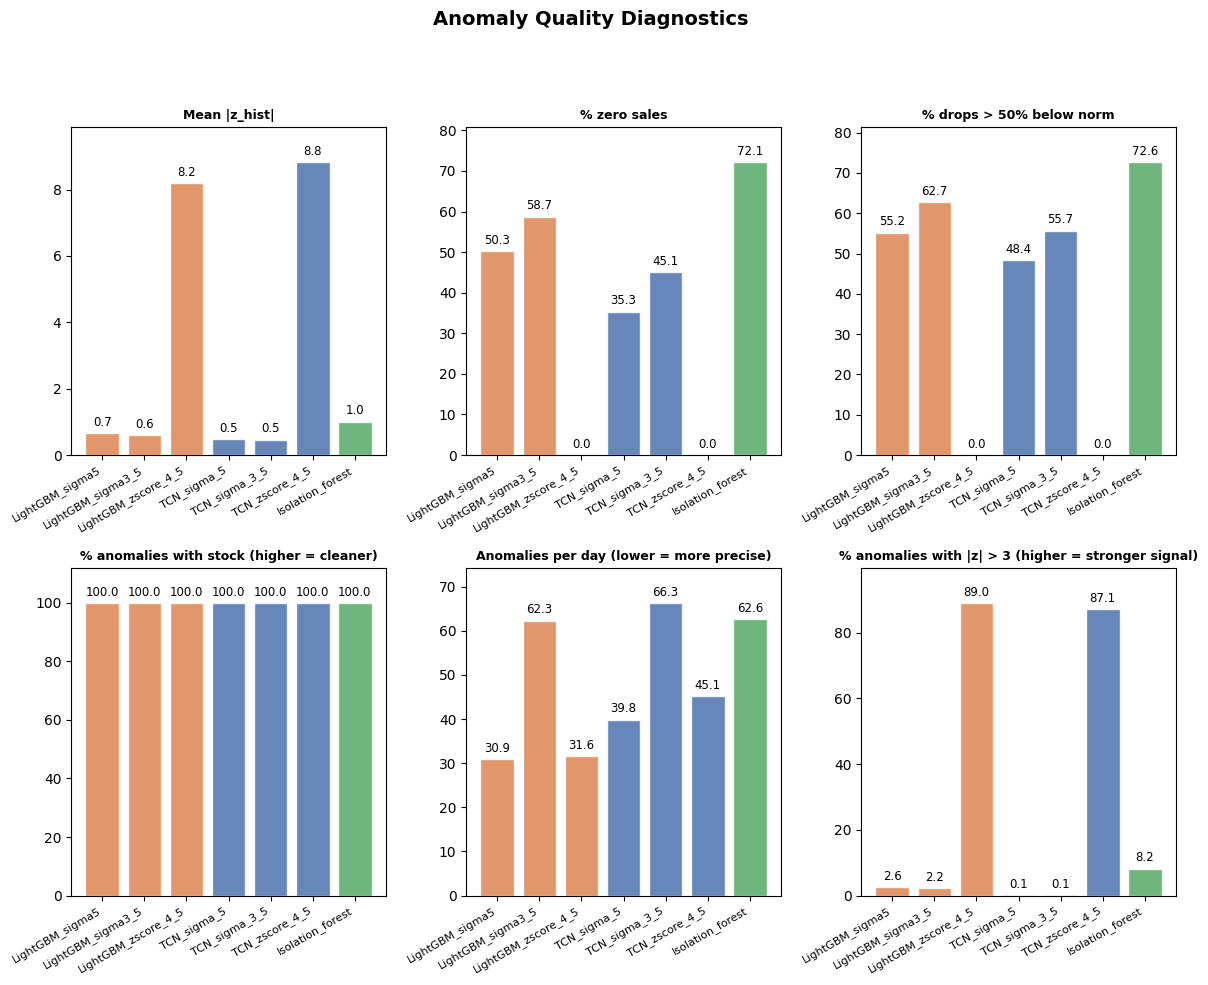

In [6]:
summary = pd.DataFrame(all_metrics).set_index('Model').T
display(summary.style.set_caption("Model Comparison — Signal Quality Diagnostics")
        .set_properties(**{'text-align': 'center', 'font-size': '11px'}))

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

names = [m['Model'] for m in all_metrics]

def get_color(model_name: str) -> str:
    name = model_name.lower()
    if 'lightgbm' in name or 'lgbm' in name:
        return '#DD8452'
    elif 'tcn' in name:
        return '#4C72B0'
    elif 'isolation' in name or 'forest' in name:
        return '#55A868'
    elif 'imredi' in name:
        return '#ffe34d'
    return '#DD8452'

colors = [get_color(name) for name in names]

plots = [
    ('Mean |z_hist|', 'Mean |z_hist|'),
    ('% zero sales', '% zero sales'),
    ('% drops > 50% below norm', '% drops > 50% below norm'),
    ('% anomalies with stock', '% anomalies with stock (higher = cleaner)'),
    ('Anomalies/day (avg)', 'Anomalies per day (lower = more precise)'),
    ('% |z_hist| > 3', '% anomalies with |z| > 3 (higher = stronger signal)'),
]

for ax, (metric, title) in zip(axes, plots):
    vals = [m[metric] for m in all_metrics]
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    
    if vals:
        max_val = max(vals)
        ax.set_ylim(0, max_val * 1.12)
    
    # Подписи над барами
    for bar, val in zip(bars, vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, 
                height + max_val * 0.015,
                f'{val:.1f}' if isinstance(val, float) else str(val),
                ha='center', va='bottom', fontsize=8.5, fontweight='medium')

plt.suptitle('Anomaly Quality Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Comparative Analysis of Anomaly Detection Models

The structured statistical evaluation framework was applied to seven configurations across three architectures — **LightGBM**, **Temporal Convolutional Network (TCN)**, and **Isolation Forest** — using hourly retail sales data for August 2025.

All models successfully passed the basic operational sanity checks: detected anomalies occur exclusively during working hours (07:00–22:00) and only when stock was available, confirming that the mandatory preprocessing filters function correctly. The temporal profile of anomalies is consistent across configurations — peaking between 11:00 and 13:00 and strongly concentrated on weekdays — which aligns well with real retail sales dynamics.

At the same time, the models show substantial differences in signal quality, product coverage, and operational practicality:

- **LightGBM** delivers the strongest overall performance with two excellent configurations:
  - `LightGBM_sigma5` provides the best balance: it detects anomalies across 142 unique products with a solid mean |z_hist| of 0.667 and 5.2% of anomalies exceeding |z| > 2.
  - `LightGBM_zscore_4_5` stands out with exceptionally strong statistical signals (mean |z_hist| = 8.191, 96.6% of anomalies with |z| > 2, and 89.0% with |z| > 3) while maintaining zero zero-sale anomalies and broad coverage (138 products).
- **TCN** models tend to concentrate detections on a much narrower set of products (only 43 SKUs in `sigma=5` mode). Despite comparable or higher total alert volume, they exhibit noticeably weaker statistical significance (mean |z_hist| ≈ 0.47), indicating potential systematic over-detection on individual items.
- **Isolation Forest** produces the highest number of anomalies (1,942) and moderate product coverage (106 SKUs) with a mean |z_hist| of 1.01. However, it also generates a significantly higher proportion of zero-sale events compared to the other approaches.

A major advantage of **LightGBM** is its interpretability: as a gradient boosting model, it enables direct evaluation of each feature’s contribution to the anomaly decision. This property is critical for subsequent model refinement and for explaining results to business stakeholders. In contrast, TCN is a black-box neural architecture, and Isolation Forest offers limited interpretability.

**Conclusion**

Based on the comprehensive assessment — breadth of product coverage, statistical significance of detected anomalies, operational alert volume, and model interpretability — the **LightGBM** architecture is clearly the best choice. Both its configurations (`sigma=5` and `zscore_4.5`) demonstrate superior performance, with the **z-score_4.5** variant providing the strongest and cleanest statistical signals, and the **sigma=5** variant offering an excellent balance between coverage and practicality.

The top priority for further improvement is adaptive threshold calibration that takes into account each product’s historical frequency of positive sales. This will further reduce false positives on low-frequency items while preserving high sensitivity to genuine sales deteriorations.